In [1]:
import numpy as np
import matplotlib.pyplot as plt
import scipy as sp

from scipy.sparse import vstack, load_npz
from sklearn.preprocessing import StandardScaler
import sklearn.metrics as skm
import sklearn.utils as sku

import torch as pt
import torch.nn as nn
import torch.optim as optim

from torch.nn import CrossEntropyLoss
from torch.utils.data import Dataset, DataLoader

import optuna as opt

import Basic_functions as bf

from torchao.sparsity.training import (
    SemiSparseLinear,
    SemiSparseActivationLinear,
    swap_linear_with_semi_sparse_linear,
    swap_semi_sparse_linear_with_linear,
)

# Optional imports
# from torch.nn import L1Loss
# from scipy.special import expit

W0608 13:28:28.947000 46771 site-packages/torch/distributed/elastic/multiprocessing/redirects.py:29] NOTE: Redirects are currently not supported in Windows or MacOs.


In [4]:
import numpy as np
from scipy import sparse
from scipy.sparse import load_npz
from sklearn.preprocessing import StandardScaler
import sklearn.utils as sku

# --------------------------------------------------------
# FILE IDS TO LOAD
# --------------------------------------------------------

file_ids = [
    "00", "01", "02", "03", "04", "05", "06",
    "07", "08", "09", "10", "11", "12",
    "13", "14", "15", "16", "17", "18"
]

# --------------------------------------------------------
# PATHS
# --------------------------------------------------------

DATA_NLTK_FILE = "/Users/psf728/Desktop/data_nltk.npz"
LABEL_NLTK_FILE = "Data_files/labels_nltk.txt"

TRIGRAM_SORT_FILE = "txt_files/regression_sort_idx.txt"
NLTK_SORT_FILE = "txt_files/regression_nltk_sort_idx.txt"

# --------------------------------------------------------
# LABEL COLUMN STRUCTURE
# --------------------------------------------------------

TRI_DATE_COL = 0
TRI_SERMON_COL = 1
TRI_TITLE_COL = 2
TRI_TOPIC_COL = 3
TRI_LIX_COL = 4

NLTK_LIX_COL = 0
NLTK_TOPIC_COL = 1
NLTK_ARTICLE_COL = 2
NLTK_DATE_COL = 3

# --------------------------------------------------------
# LOAD TRIGRAM DATA
# --------------------------------------------------------

data_list = [
    load_npz(f"Data_files/data_articles_{fid}.npz")
    for fid in file_ids
]

label_list = [
    np.genfromtxt(
        f"Data_files/labels_articles_{fid}.txt",
        delimiter="; ",
        dtype=str,
        encoding="latin1"
    )
    for fid in file_ids
]

data_trigram = sparse.vstack(data_list, format="csr")
labels_trigram = np.vstack(label_list)

assert data_trigram.shape[0] == labels_trigram.shape[0]

print("Initial trigram data shape:", data_trigram.shape)
print("Initial trigram labels:", labels_trigram.shape[0])

# --------------------------------------------------------
# FIND TOP X TOPICS FROM TRIGRAM DATA
# --------------------------------------------------------

top_x = 10

topics_trigram = labels_trigram[:, TRI_TOPIC_COL]

unique_topics, topic_counts = np.unique(
    topics_trigram,
    return_counts=True
)

sorted_indices = np.argsort(topic_counts)[::-1]
valid_topics = unique_topics[sorted_indices[:top_x]]

keep_mask_trigram = np.isin(
    topics_trigram,
    valid_topics
)

print("\nOriginal number of trigram articles:", data_trigram.shape[0])
print("Filtered number of trigram articles:", keep_mask_trigram.sum())
print("Removed trigram articles:", data_trigram.shape[0] - keep_mask_trigram.sum())

print("\nTop topics kept:")
for topic in valid_topics:
    print(f"{topic}: {np.sum(topics_trigram == topic)}")

data_trigram = data_trigram[keep_mask_trigram]
labels_trigram = labels_trigram[keep_mask_trigram]

assert data_trigram.shape[0] == labels_trigram.shape[0]

# --------------------------------------------------------
# ADD LIX SCORE TO TRIGRAM DATA ONLY
# --------------------------------------------------------

lix_scores_trigram = labels_trigram[:, TRI_LIX_COL].astype(np.float32)

lix_column = sparse.csr_matrix(
    lix_scores_trigram.reshape(-1, 1)
)

data_trigram = sparse.hstack(
    [lix_column, data_trigram],
    format="csr"
)

print("\nShape after adding LIX to trigram data:", data_trigram.shape)

# --------------------------------------------------------
# SORT / COMB TRIGRAM + LIX FEATURES
# --------------------------------------------------------

sort_idx_trigram = np.genfromtxt(
    TRIGRAM_SORT_FILE,
    delimiter="\n",
    dtype=int
)

print("\nTrigram columns before sorting:", data_trigram.shape[1])
print("Smallest trigram sort index:", sort_idx_trigram.min())
print("Largest trigram sort index:", sort_idx_trigram.max())

sort_idx_trigram = sort_idx_trigram[
    sort_idx_trigram < data_trigram.shape[1]
]

data_trigram = data_trigram[:, sort_idx_trigram][:, :5000]

print("Shape after trigram combing:", data_trigram.shape)

# --------------------------------------------------------
# CREATE TRIGRAM DATE LABELS
# --------------------------------------------------------

y_trigram = labels_trigram[:, TRI_DATE_COL].astype(np.float32)

# --------------------------------------------------------
# LOAD NLTK DATA
# --------------------------------------------------------

data_nltk = load_npz(DATA_NLTK_FILE)

labels_nltk = np.genfromtxt(
    LABEL_NLTK_FILE,
    delimiter=";",
    dtype=str,
    skip_header=1
)

assert data_nltk.shape[0] == labels_nltk.shape[0]

print("\nInitial NLTK data shape:", data_nltk.shape)
print("Initial NLTK labels:", labels_nltk.shape[0])

# --------------------------------------------------------
# FILTER NLTK TO ARTICLES ONLY
# --------------------------------------------------------

article_mask_nltk = labels_nltk[:, NLTK_ARTICLE_COL].astype(int) == 1

data_nltk = data_nltk[article_mask_nltk]
labels_nltk = labels_nltk[article_mask_nltk]

print("\nNLTK articles kept:", data_nltk.shape[0])

# --------------------------------------------------------
# FILTER NLTK TO SAME TOPICS AS TRIGRAM DATA
# --------------------------------------------------------

topics_nltk = labels_nltk[:, NLTK_TOPIC_COL]

keep_mask_nltk = np.isin(
    topics_nltk,
    valid_topics
)

data_nltk = data_nltk[keep_mask_nltk]
labels_nltk = labels_nltk[keep_mask_nltk]

assert data_nltk.shape[0] == labels_nltk.shape[0]

print("NLTK articles after top-topic filtering:", data_nltk.shape[0])

# --------------------------------------------------------
# SORT / COMB NLTK FEATURES
# --------------------------------------------------------

sort_idx_nltk = np.genfromtxt(
    NLTK_SORT_FILE,
    delimiter="\n",
    dtype=int
)

print("\nNLTK columns before sorting:", data_nltk.shape[1])
print("Smallest NLTK sort index:", sort_idx_nltk.min())
print("Largest NLTK sort index:", sort_idx_nltk.max())

# NLTK sort file was made for [LIX + NLTK].
# Since LIX should NOT be added to the NLTK part,
# remove LIX index 0 and shift the rest down by 1.
sort_idx_nltk = sort_idx_nltk[sort_idx_nltk > 0] - 1

sort_idx_nltk = sort_idx_nltk[
    sort_idx_nltk < data_nltk.shape[1]
]

data_nltk = data_nltk[:, sort_idx_nltk][:, :20000]

print("Shape after NLTK combing:", data_nltk.shape)

# --------------------------------------------------------
# CREATE NLTK DATE LABELS
# --------------------------------------------------------

y_nltk = labels_nltk[:, NLTK_DATE_COL].astype(np.float32)

# --------------------------------------------------------
# MAKE BOTH MATRICES COMPATIBLE FOR VERTICAL STACKING
# --------------------------------------------------------

n_trigram_rows = data_trigram.shape[0]
n_nltk_rows = data_nltk.shape[0]

n_trigram_features = data_trigram.shape[1]
n_nltk_features = data_nltk.shape[1]

zeros_for_nltk_part = sparse.csr_matrix(
    (n_trigram_rows, n_nltk_features)
)

zeros_for_trigram_part = sparse.csr_matrix(
    (n_nltk_rows, n_trigram_features)
)

data_trigram_block = sparse.hstack(
    [data_trigram, zeros_for_nltk_part],
    format="csr"
)

data_nltk_block = sparse.hstack(
    [zeros_for_trigram_part, data_nltk],
    format="csr"
)

# --------------------------------------------------------
# COMBINE TRIGRAM AND NLTK AS ONE LONG DATASET
# --------------------------------------------------------

data_all = sparse.vstack(
    [data_trigram_block, data_nltk_block],
    format="csr"
)

y_dates = np.concatenate(
    [y_trigram, y_nltk]
)

assert data_all.shape[0] == y_dates.shape[0]

print("\nCombined data shape before scaling:", data_all.shape)
print("Combined date labels:", y_dates.shape[0])

# --------------------------------------------------------
# SCALE FULL FEATURE MATRIX
# --------------------------------------------------------

scaler = StandardScaler(with_mean=False)

data_all = scaler.fit_transform(
    data_all
)

print("Shape after scaling:", data_all.shape)

# --------------------------------------------------------
# SHUFFLE FINAL DATASET
# --------------------------------------------------------

data_all, y_dates = sku.shuffle(
    data_all,
    y_dates,
    random_state=5466542
)

# --------------------------------------------------------
# FINAL OUTPUT
# --------------------------------------------------------

print("\nFinal data shape:", data_all.shape)
print("Final number of date labels:", y_dates.shape[0])

print("\nDate label summary:")
print("Min year:", y_dates.min())
print("Max year:", y_dates.max())
print("Mean year:", y_dates.mean())
print("Number of unique dates:", len(np.unique(y_dates)))

print("\nExample feature row:")
print(data_all[0])

print("\nExample date label:")
print(y_dates[0])

Initial trigram data shape: (853077, 27000)
Initial trigram labels: 853077

Original number of trigram articles: 853077
Filtered number of trigram articles: 504327
Removed trigram articles: 348750

Top topics kept:
Danmark: 150348
Internationalt: 144647
Sport: 42216
Kultur: 35301
Politik: 34656
Økonomi: 30938
Fodbold: 27503
Forbrug: 13721
Film og tv: 13120
Cykling: 11877

Shape after adding LIX to trigram data: (504327, 27001)

Trigram columns before sorting: 27001
Smallest trigram sort index: 0
Largest trigram sort index: 27000
Shape after trigram combing: (504327, 5000)

Initial NLTK data shape: (780044, 64478)
Initial NLTK labels: 780044

NLTK articles kept: 775291
NLTK articles after top-topic filtering: 434564

NLTK columns before sorting: 64478
Smallest NLTK sort index: 0
Largest NLTK sort index: 64478
Shape after NLTK combing: (434564, 20000)

Combined data shape before scaling: (938891, 25000)
Combined date labels: 938891
Shape after scaling: (938891, 25000)

Final data shape: 

In [3]:
print("Trigram label example:")
print(labels_articles_all[0])

print("\nNLTK label example:")
print(labels_nltk_all[0])

Trigram label example:
['2001.393607305936' '0' 'nan' 'Kultur' '31.556790123456793']

NLTK label example:
['42.78139534883721' 'Kultur' '1' '2004.424885844749']


In [ ]:
#class MyDataset(Dataset):    
    #def __init__(self, X_data, y_data):
        #self.input = X_data
        #self.truth = y_data
        
    #def __getitem__(self, index):
        #return self.input[index], self.truth[index]
        
    #def __len__ (self):
        #return self.truth.shape[0]

#In pytorch, there is an additional step of turning your data into tensors
#train_data = MyDataset(data_train, data_train_labels)
#val_data = MyDataset(data_val, data_val_labels)

import numpy as np
import pandas as pd
import torch as pt
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt

from tqdm.auto import tqdm

from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# --------------------------------------------------------
# CREATE REGRESSION TARGET FROM ARTICLE DATE
# --------------------------------------------------------

y_years = labels_articles_all[:, 0].astype(np.float32)

valid_date_mask = ~np.isnan(y_years)

X_reg = data_articles_all[valid_date_mask]
y_years = y_years[valid_date_mask]

print("Earliest year:", y_years.min())
print("Latest year:", y_years.max())
print("Number of articles:", X_reg.shape[0])

y_scaler = StandardScaler()

y_scaled = y_scaler.fit_transform(
    y_years.reshape(-1, 1)
).astype(np.float32)

# --------------------------------------------------------
# SPLIT REGRESSION DATA INTO TRAIN, VAL, TEST SETS
# --------------------------------------------------------

X_train, X_val, y_train, y_val = train_test_split(
    X_reg,
    y_scaled,
    test_size=0.2,
    random_state=42
)


print("Train size:", X_train.shape[0])
print("Validation size:", X_val.shape[0])
#print("Test size:", X_test.shape[0])

class MyDataset(Dataset):    
    def __init__(self, X_data, y_data):
        self.input = X_data
        self.truth = y_data
        
    def __getitem__(self, index):
        return self.input[index], self.truth[index]
        
    def __len__ (self):
        return self.truth.shape[0]

#In pytorch, there is an additional step of turning your data into tensors
train_data_reg = MyDataset(X_train, y_train)
val_data_reg = MyDataset(X_val, y_val)

Earliest year: 2000.1052
Latest year: 2026.4714
Number of articles: 504327
Train size: 403461
Validation size: 100866


In [ ]:
# Training loop:
def Train(model, optimizer, loss_function, train_loader, validation_loader, device, epochs):
    validation_loss = []
    training_loss   = []
    model.train()
    for e in range(0, epochs):
        epoch_loss = 0
        n_minibatches = 0
        for input_train_batch, truth_train_batch in train_loader:
            input_train_batch, truth_train_batch = input_train_batch.to(device), truth_train_batch.to(device)
            optimizer.zero_grad()
            prediction = model(input_train_batch)  # This asks our model to produce predictions on the training batch            
            loss = loss_function(prediction, truth_train_batch.long())  # This calculates the loss
            loss.backward()                                             # This initiates the backpropagation
            optimizer.step()
            epoch_loss += loss.item()
            n_minibatches += 1
        
        # Now that the model have trained 1 epoch, we evaluate the model on the validation set:
        valid_loss = Validate(model, validation_loader, device, loss_function)
        validation_loss.append(valid_loss)
        training_loss.append(epoch_loss/n_minibatches)
        print('EPOCH: %s | training loss: %s  | validation loss: %s'%(e+1,round(epoch_loss/n_minibatches,3), round(valid_loss, 3)))
    return training_loss, validation_loss


def Validate(model, validation_loader, device, loss_function):
    model.eval()
    n_batches  = 0
    validation_loss = 0
    with pt.no_grad():
        for input_valid_batch, truth_valid_batch in validation_loader:
            input_valid_batch, truth_valid_batch = input_valid_batch.to(device), truth_valid_batch.to(device)
            prediction = model(input_valid_batch)
            loss = loss_function(prediction, truth_valid_batch.long())
            validation_loss += loss.item()
            n_batches += 1
    validation_loss = validation_loss/n_batches
    return validation_loss


def Predict(model, prediction_loader, device):
    model.eval()
    predictions = []
    print('PREDICTING!')
    with pt.no_grad():
        for input_pred_batch, _ in prediction_loader:
            input_pred_batch = input_pred_batch.to(device)
            prediction = model(input_pred_batch)
            predictions.extend(prediction.numpy())
    print('Done Predicting!')
    return predictions
                
class MeanRelativeAbsoluteDeviationLoss(nn.Module):
    def __init__(self, eps=1e-8):
        super().__init__()
        self.eps = eps
                
    def forward(self, prediction, target):
        prediction = prediction.view_as(target)
        relative_absolute_error = pt.abs(prediction - target) / (pt.abs(target) + self.eps)
        return pt.mean(relative_absolute_error)

In [ ]:
def sparse_collate(batch):
    xs, ys = zip(*batch)

    first = xs[0]
    n_features = first.shape[-1]

    batch_rows = []
    batch_cols = []
    batch_vals = []

    for i, x in enumerate(xs):
        x = x.tocoo()
        batch_rows.append(np.full_like(x.col, i, dtype=np.int64))
        batch_cols.append(x.col.astype(np.int64))
        batch_vals.append(x.data.astype(np.float32))

    indices = pt.tensor(
        np.vstack([np.concatenate(batch_rows), np.concatenate(batch_cols)]),
        dtype=pt.long
    )
    values = pt.tensor(np.concatenate(batch_vals), dtype=pt.float32)

    X = pt.sparse_coo_tensor(indices, values, size=(len(xs), n_features)).coalesce()
    y = pt.tensor(np.asarray(ys), dtype=pt.long)
    return X, y

In [ ]:
N_mult = 2
def objective(trial):

    learning_rate = trial.suggest_float(
        "learning_rate",
        1e-5,
        1e-3,
        log=True
    )

    batch_size = trial.suggest_categorical(
        "batch_size",
        [2,4,8,16,32,64,128]
    )

    Layer1 = trial.suggest_int("Layer1", 128*N_mult, 512*N_mult)
    Layer2 = trial.suggest_int("Layer2", 64*N_mult, 256*N_mult)
    Layer3 = trial.suggest_int("Layer3", 16*N_mult, 64*N_mult)

    dropout_rate = trial.suggest_float(
        "dropout_rate",
        0.1,
        0.5
    )

    weight_decay = trial.suggest_float(
        "weight_decay",
        1e-6,
        1e-3,
        log=True
    )

    n_epochs = 5

    input_dim = X_train.shape[1]

    class OptRegressionModel(nn.Module):

        def __init__(self):
            super(OptRegressionModel, self).__init__()

            self.input_layer = nn.Linear(input_dim, Layer1)
            self.hidden_layer1 = nn.Linear(Layer1, Layer2)
            self.hidden_layer2 = nn.Linear(Layer2, Layer3)
            self.output_layer = nn.Linear(Layer3, 1)

            self.relu = nn.ReLU()
            self.dropout = nn.Dropout(dropout_rate)

        def forward(self, inputs):

            x = self.input_layer(inputs)
            x = self.relu(x)
            x = self.dropout(x)

            x = self.hidden_layer1(x)
            x = self.relu(x)
            x = self.dropout(x)

            x = self.hidden_layer2(x)
            x = self.relu(x)

            x = self.output_layer(x)

            return x

    device = pt.device(
        "cuda" if pt.cuda.is_available() else "cpu"
    )

    model_opt = OptRegressionModel().to(device)

    loss_function = nn.MSELoss()

    optimizer = optim.Adam(
        model_opt.parameters(),
        lr=learning_rate,
        weight_decay=weight_decay
    )

    train_loader = DataLoader(
        dataset=train_data_reg,
        batch_size=batch_size,
        shuffle=True
    )

    validation_loader = DataLoader(
        dataset=val_data_reg,
        batch_size=batch_size,
        shuffle=False
    )

    best_validation_loss = float("inf")

    epoch_bar = tqdm(
        range(n_epochs),
        desc=f"Trial {trial.number}",
        leave=False,
        unit="epoch"
    )

    for epoch in epoch_bar:

        model_opt.train()
        epoch_training_loss = 0

        for input_batch, truth_batch in train_loader:

            input_batch = input_batch.to(device)
            truth_batch = truth_batch.to(device)

            optimizer.zero_grad()

            predictions = model_opt(input_batch).squeeze()

            loss = loss_function(
                predictions,
                truth_batch
            )

            loss.backward()
            optimizer.step()

            epoch_training_loss += loss.item()

        epoch_training_loss /= len(train_loader)

        model_opt.eval()
        epoch_validation_loss = 0

        with pt.no_grad():

            for input_batch, truth_batch in validation_loader:

                input_batch = input_batch.to(device)
                truth_batch = truth_batch.to(device)

                predictions = model_opt(input_batch).squeeze()

                loss = loss_function(
                    predictions,
                    truth_batch
                )

                epoch_validation_loss += loss.item()

        epoch_validation_loss /= len(validation_loader)

        best_validation_loss = min(
            best_validation_loss,
            epoch_validation_loss
        )

        epoch_bar.set_postfix(
            train_loss=f"{epoch_training_loss:.4f}",
            val_loss=f"{epoch_validation_loss:.4f}",
            best=f"{best_validation_loss:.4f}"
        )

        trial.report(epoch_validation_loss, epoch)

        if trial.should_prune():
            raise opt.exceptions.TrialPruned()

    return best_validation_loss

In [ ]:
def progress_callback(study, trial):

    optuna_bar.update(1)

    if study.best_trial is not None:
        optuna_bar.set_postfix(
            best_loss=f"{study.best_value:.4f}",
            best_trial=study.best_trial.number
        )

# HP optimization

In [ ]:
class SparseRegressionDataset(Dataset):

    def __init__(self, X, y):
        self.X = X
        self.y = y

    def __len__(self):
        return self.X.shape[0]

    def __getitem__(self, idx):
        x = self.X[idx].toarray().squeeze()
        y = self.y[idx]

        return (
            pt.tensor(x, dtype=pt.float32),
            pt.tensor(y, dtype=pt.float32)
        )

train_data_reg = SparseRegressionDataset(X_train, y_train)
val_data_reg = SparseRegressionDataset(X_val, y_val)
#test_data_reg = SparseRegressionDataset(X_test, y_test)

In [ ]:
from tqdm.auto import tqdm

n_trials = 50

pruner = opt.pruners.MedianPruner(
    n_startup_trials=2,
    n_warmup_steps=1
)

study = opt.create_study(
    direction="minimize",
    pruner=pruner
)

optuna_bar = tqdm(
    total=n_trials,
    desc="Optuna Trials",
    unit="trial"
)

device = pt.device(
    "cuda" if pt.cuda.is_available() else "cpu"
)

print(device)

study.optimize(
    objective,
    n_trials=n_trials,
    callbacks=[progress_callback]
)

optuna_bar.close()

print("Best trial:")
print(study.best_trial)

print("Best parameters:")
print(study.best_trial.params)

best_params = study.best_trial.params

learning_rate = best_params["learning_rate"]
batch_size = best_params["batch_size"]
dropout_rate = best_params["dropout_rate"]
weight_decay = best_params["weight_decay"]

Layer1 = best_params["Layer1"]
Layer2 = best_params["Layer2"]
Layer3 = best_params["Layer3"]

[I 2026-06-06 17:24:45,332] A new study created in memory with name: no-name-b9cb226e-1e10-464d-9e00-d7b8d812c1a8


Optuna Trials:   0%|          | 0/50 [00:00<?, ?trial/s]

cpu


Trial 0:   0%|          | 0/5 [00:00<?, ?epoch/s]

/opt/anaconda3/envs/app-ml/lib/python3.12/site-packages/torch/nn/modules/loss.py:626: UserWarning: Using a target size (torch.Size([16, 1])) that is different to the input size (torch.Size([16])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  return F.mse_loss(input, target, reduction=self.reduction)
/opt/anaconda3/envs/app-ml/lib/python3.12/site-packages/torch/nn/modules/loss.py:626: UserWarning: Using a target size (torch.Size([5, 1])) that is different to the input size (torch.Size([5])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  return F.mse_loss(input, target, reduction=self.reduction)
/opt/anaconda3/envs/app-ml/lib/python3.12/site-packages/torch/nn/modules/loss.py:626: UserWarning: Using a target size (torch.Size([2, 1])) that is different to the input size (torch.Size([2])). This will likely lead to incorrect results due to broadcasting. Please ensure they ha

...

Trial 48:   0%|          | 0/5 [00:00<?, ?epoch/s]

[I 2026-06-07 10:22:31,462] Trial 48 pruned. 


Trial 49:   0%|          | 0/5 [00:00<?, ?epoch/s]

[I 2026-06-07 10:33:18,618] Trial 49 pruned. 


Best trial:
FrozenTrial(number=42, state=<TrialState.COMPLETE: 1>, values=[0.9940481103950791], datetime_start=datetime.datetime(2026, 6, 7, 8, 15, 3, 960511), datetime_complete=datetime.datetime(2026, 6, 7, 8, 40, 9, 729715), params={'learning_rate': 1.3198332476704938e-05, 'batch_size': 16, 'Layer1': 937, 'Layer2': 163, 'Layer3': 121, 'dropout_rate': 0.13002169716019144, 'weight_decay': 6.14736811540374e-06}, user_attrs={}, system_attrs={}, intermediate_values={0: 0.9946953014283781, 1: 0.9942729198961008, 2: 0.9941967375499686, 3: 0.9941100153820936, 4: 0.9940481103950791}, distributions={'learning_rate': FloatDistribution(high=0.001, log=True, low=1e-05, step=None), 'batch_size': CategoricalDistribution(choices=(16, 32, 64)), 'Layer1': IntDistribution(high=1024, log=False, low=256, step=1), 'Layer2': IntDistribution(high=512, log=False, low=128, step=1), 'Layer3': IntDistribution(high=128, log=False, low=32, step=1), 'dropout_rate': FloatDistribution(high=0.5, log=False, low=0.1, s

# Split data before training

In [ ]:
#class MyDataset(Dataset):    
    #def __init__(self, X_data, y_data):
        #self.input = X_data
        #self.truth = y_data
        
    #def __getitem__(self, index):
        #return self.input[index], self.truth[index]
        
    #def __len__ (self):
        #return self.truth.shape[0]

#In pytorch, there is an additional step of turning your data into tensors
#train_data = MyDataset(data_train, data_train_labels)
#val_data = MyDataset(data_val, data_val_labels)

import numpy as np
import pandas as pd
import torch as pt
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt

from tqdm.auto import tqdm

from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# --------------------------------------------------------
# CREATE REGRESSION TARGET FROM ARTICLE DATE
# --------------------------------------------------------

y_years = labels_articles_all[:, 0].astype(np.float32)

valid_date_mask = ~np.isnan(y_years)

X_reg = data_articles_all[valid_date_mask]
y_years = y_years[valid_date_mask]

print("Earliest year:", y_years.min())
print("Latest year:", y_years.max())
print("Number of articles:", X_reg.shape[0])

y_scaler = StandardScaler()

y_scaled = y_scaler.fit_transform(
    y_years.reshape(-1, 1)
).astype(np.float32)

# --------------------------------------------------------
# SPLIT REGRESSION DATA INTO TRAIN, VAL, TEST SETS
# --------------------------------------------------------

X_train_temp, X_test, y_train_temp, y_test = train_test_split(
    X_reg,
    y_scaled,
    test_size=0.1,
    random_state=42
)

X_train, X_val, y_train, y_val = train_test_split(
    X_train_temp,
    y_train_temp,
    test_size=0.20,
    random_state=42
)

print("Train size:", X_train.shape[0])
print("Validation size:", X_val.shape[0])
print("Test size:", X_test.shape[0])

class MyDataset(Dataset):    
    def __init__(self, X_data, y_data):
        self.input = X_data
        self.truth = y_data
        
    def __getitem__(self, index):
        return self.input[index], self.truth[index]
        
    def __len__ (self):
        return self.truth.shape[0]

#In pytorch, there is an additional step of turning your data into tensors
train_data_reg = MyDataset(X_train, y_train)
val_data_reg = MyDataset(X_val, y_val)

class SparseRegressionDataset(Dataset):

    def __init__(self, X, y):
        self.X = X
        self.y = y

    def __len__(self):
        return self.X.shape[0]

    def __getitem__(self, idx):
        x = self.X[idx].toarray().squeeze()
        y = self.y[idx]

        return (
            pt.tensor(x, dtype=pt.float32),
            pt.tensor(y, dtype=pt.float32)
        )

train_data_reg = SparseRegressionDataset(X_train, y_train)
val_data_reg = SparseRegressionDataset(X_val, y_val)
test_data_reg = SparseRegressionDataset(X_test, y_test)

Earliest year: 2000.1052
Latest year: 2026.4714
Number of articles: 504327
Train size: 363115
Validation size: 90779
Test size: 50433


# Training

In [ ]:
import torch as pt
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from tqdm.auto import tqdm
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

input_dim = X_train.shape[1]

learning_rate = best_params["learning_rate"]
batch_size = best_params["batch_size"]
weight_decay = best_params["weight_decay"]

Layer1 = best_params["Layer1"]
Layer2 = best_params["Layer2"]
Layer3 = best_params["Layer3"]

# Lower dropout for regression
dropout_rate = min(best_params["dropout_rate"], 0.15)

class DateRegressionModel(nn.Module):
    def __init__(self):
        super().__init__()

        self.network = nn.Sequential(
            nn.Linear(input_dim, Layer1),
            nn.BatchNorm1d(Layer1),
            nn.GELU(),
            nn.Dropout(dropout_rate),

            nn.Linear(Layer1, Layer2),
            nn.BatchNorm1d(Layer2),
            nn.GELU(),
            nn.Dropout(dropout_rate),

            nn.Linear(Layer2, Layer3),
            nn.GELU(),

            nn.Linear(Layer3, 1)
        )

    def forward(self, x):
        return self.network(x)

device = pt.device("cuda" if pt.cuda.is_available() else "cpu")
model = DateRegressionModel().to(device)

optimizer = optim.AdamW(
    model.parameters(),
    lr=learning_rate,
    weight_decay=weight_decay
)

loss_function = nn.SmoothL1Loss(beta=0.5)

train_loader = DataLoader(train_data_reg, batch_size=batch_size, shuffle=True)
validation_loader = DataLoader(val_data_reg, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_data_reg, batch_size=batch_size, shuffle=False)

n_epochs = 10
patience = 7

best_val_loss = np.inf
best_state = None
bad_epochs = 0

training_loss = []
validation_loss = []

for epoch in tqdm(range(n_epochs)):

    model.train()
    train_loss = 0

    for xb, yb in train_loader:
        xb = xb.to(device)
        yb = yb.to(device).view(-1, 1)

        optimizer.zero_grad()
        pred = model(xb)

        loss = loss_function(pred, yb)
        loss.backward()

        nn.utils.clip_grad_norm_(model.parameters(), 1.0)

        optimizer.step()
        train_loss += loss.item()

    train_loss /= len(train_loader)

    model.eval()
    val_loss = 0

    with pt.no_grad():
        for xb, yb in validation_loader:
            xb = xb.to(device)
            yb = yb.to(device).view(-1, 1)

            pred = model(xb)
            loss = loss_function(pred, yb)

            val_loss += loss.item()

    val_loss /= len(validation_loader)

    training_loss.append(train_loss)
    validation_loss.append(val_loss)

    print(
        f"Epoch {epoch+1:03d} | "
        f"train loss {train_loss:.4f} | "
        f"val loss {val_loss:.4f}"
    )

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_state = model.state_dict()
        bad_epochs = 0
    else:
        bad_epochs += 1

    if bad_epochs >= patience:
        print("Early stopping")
        break

model.load_state_dict(best_state)

  0%|          | 0/10 [00:00<?, ?it/s]

Epoch 001 | train loss 0.2694 | val loss 0.1953
Epoch 002 | train loss 0.1882 | val loss 0.1713
Epoch 003 | train loss 0.1610 | val loss 0.1637
Epoch 004 | train loss 0.1431 | val loss 0.1551
Epoch 005 | train loss 0.1289 | val loss 0.1651
Epoch 006 | train loss 0.1174 | val loss 0.1717
Epoch 007 | train loss 0.1086 | val loss 0.1529
Epoch 008 | train loss 0.1009 | val loss 0.1527
Epoch 009 | train loss 0.0939 | val loss 0.1582
Epoch 010 | train loss 0.0887 | val loss 0.1461


<All keys matched successfully>

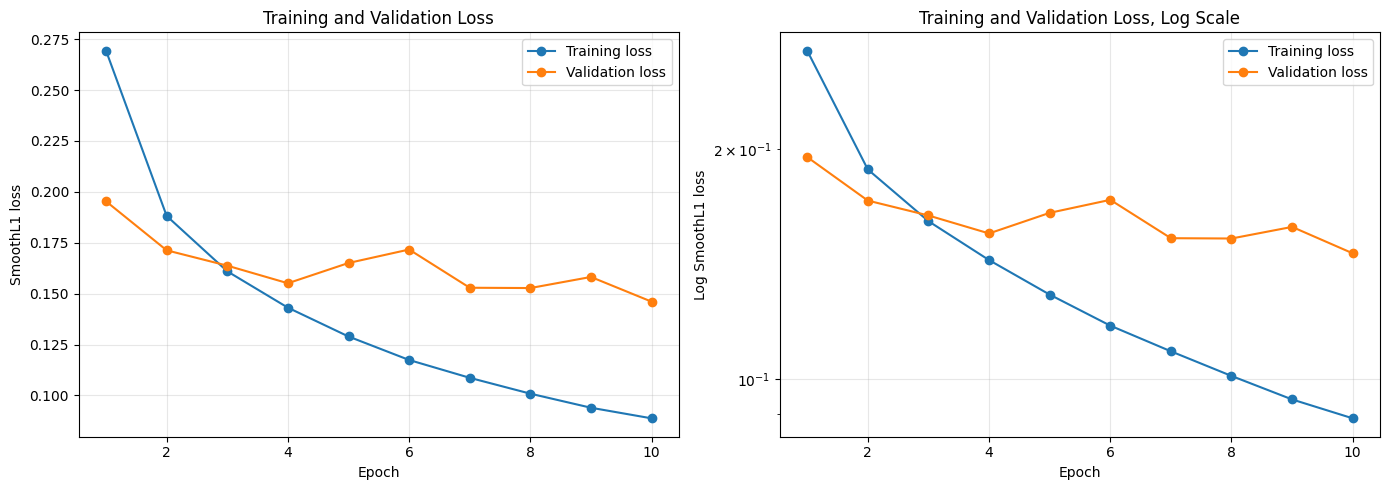

Final training loss     : 0.088729
Final validation loss   : 0.146061
Best validation loss    : 0.146061
Best validation epoch   : 10

Log losses:
Log final training loss   : -2.422172
Log final validation loss : -1.923731
Log best validation loss  : -1.923731


In [ ]:
import matplotlib.pyplot as plt
import numpy as np

epochs = np.arange(1, len(training_loss) + 1)

fig, axs = plt.subplots(1, 2, figsize=(14, 5))

# --------------------------------------------------------
# NORMAL LOSS PLOT
# --------------------------------------------------------

axs[0].plot(epochs, training_loss, marker="o", label="Training loss")
axs[0].plot(epochs, validation_loss, marker="o", label="Validation loss")

axs[0].set_xlabel("Epoch")
axs[0].set_ylabel("SmoothL1 loss")
axs[0].set_title("Training and Validation Loss")
axs[0].legend()
axs[0].grid(alpha=0.3)

# --------------------------------------------------------
# LOG-SCALE LOSS PLOT
# --------------------------------------------------------

axs[1].plot(epochs, training_loss, marker="o", label="Training loss")
axs[1].plot(epochs, validation_loss, marker="o", label="Validation loss")

axs[1].set_yscale("log")
axs[1].set_xlabel("Epoch")
axs[1].set_ylabel("Log SmoothL1 loss")
axs[1].set_title("Training and Validation Loss, Log Scale")
axs[1].legend()
axs[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

# --------------------------------------------------------
# PRINT FINAL LOSSES
# --------------------------------------------------------

print(f"Final training loss     : {training_loss[-1]:.6f}")
print(f"Final validation loss   : {validation_loss[-1]:.6f}")
print(f"Best validation loss    : {min(validation_loss):.6f}")

best_epoch = np.argmin(validation_loss) + 1
print(f"Best validation epoch   : {best_epoch}")

# Optional explicit log values
eps = 1e-12

print("\nLog losses:")
print(f"Log final training loss   : {np.log(training_loss[-1] + eps):.6f}")
print(f"Log final validation loss : {np.log(validation_loss[-1] + eps):.6f}")
print(f"Log best validation loss  : {np.log(min(validation_loss) + eps):.6f}")

# Test

In [ ]:
model.eval()
test_predictions_scaled = []

with pt.no_grad():
    for xb, _ in test_loader:
        xb = xb.to(device)
        pred = model(xb).cpu().numpy()
        test_predictions_scaled.append(pred)

test_predictions_scaled = np.vstack(test_predictions_scaled)

true_test_years = y_scaler.inverse_transform(y_test.reshape(-1, 1)).ravel()
predicted_test_years = y_scaler.inverse_transform(test_predictions_scaled).ravel()

mae = mean_absolute_error(true_test_years, predicted_test_years)
rmse = np.sqrt(mean_squared_error(true_test_years, predicted_test_years))
r2 = r2_score(true_test_years, predicted_test_years)

print(f"MAE  : {mae:.3f} years")
print(f"RMSE : {rmse:.3f} years")
print(f"R²   : {r2:.3f}")

MAE  : 2.026 years
RMSE : 2.784 years
R²   : 0.824


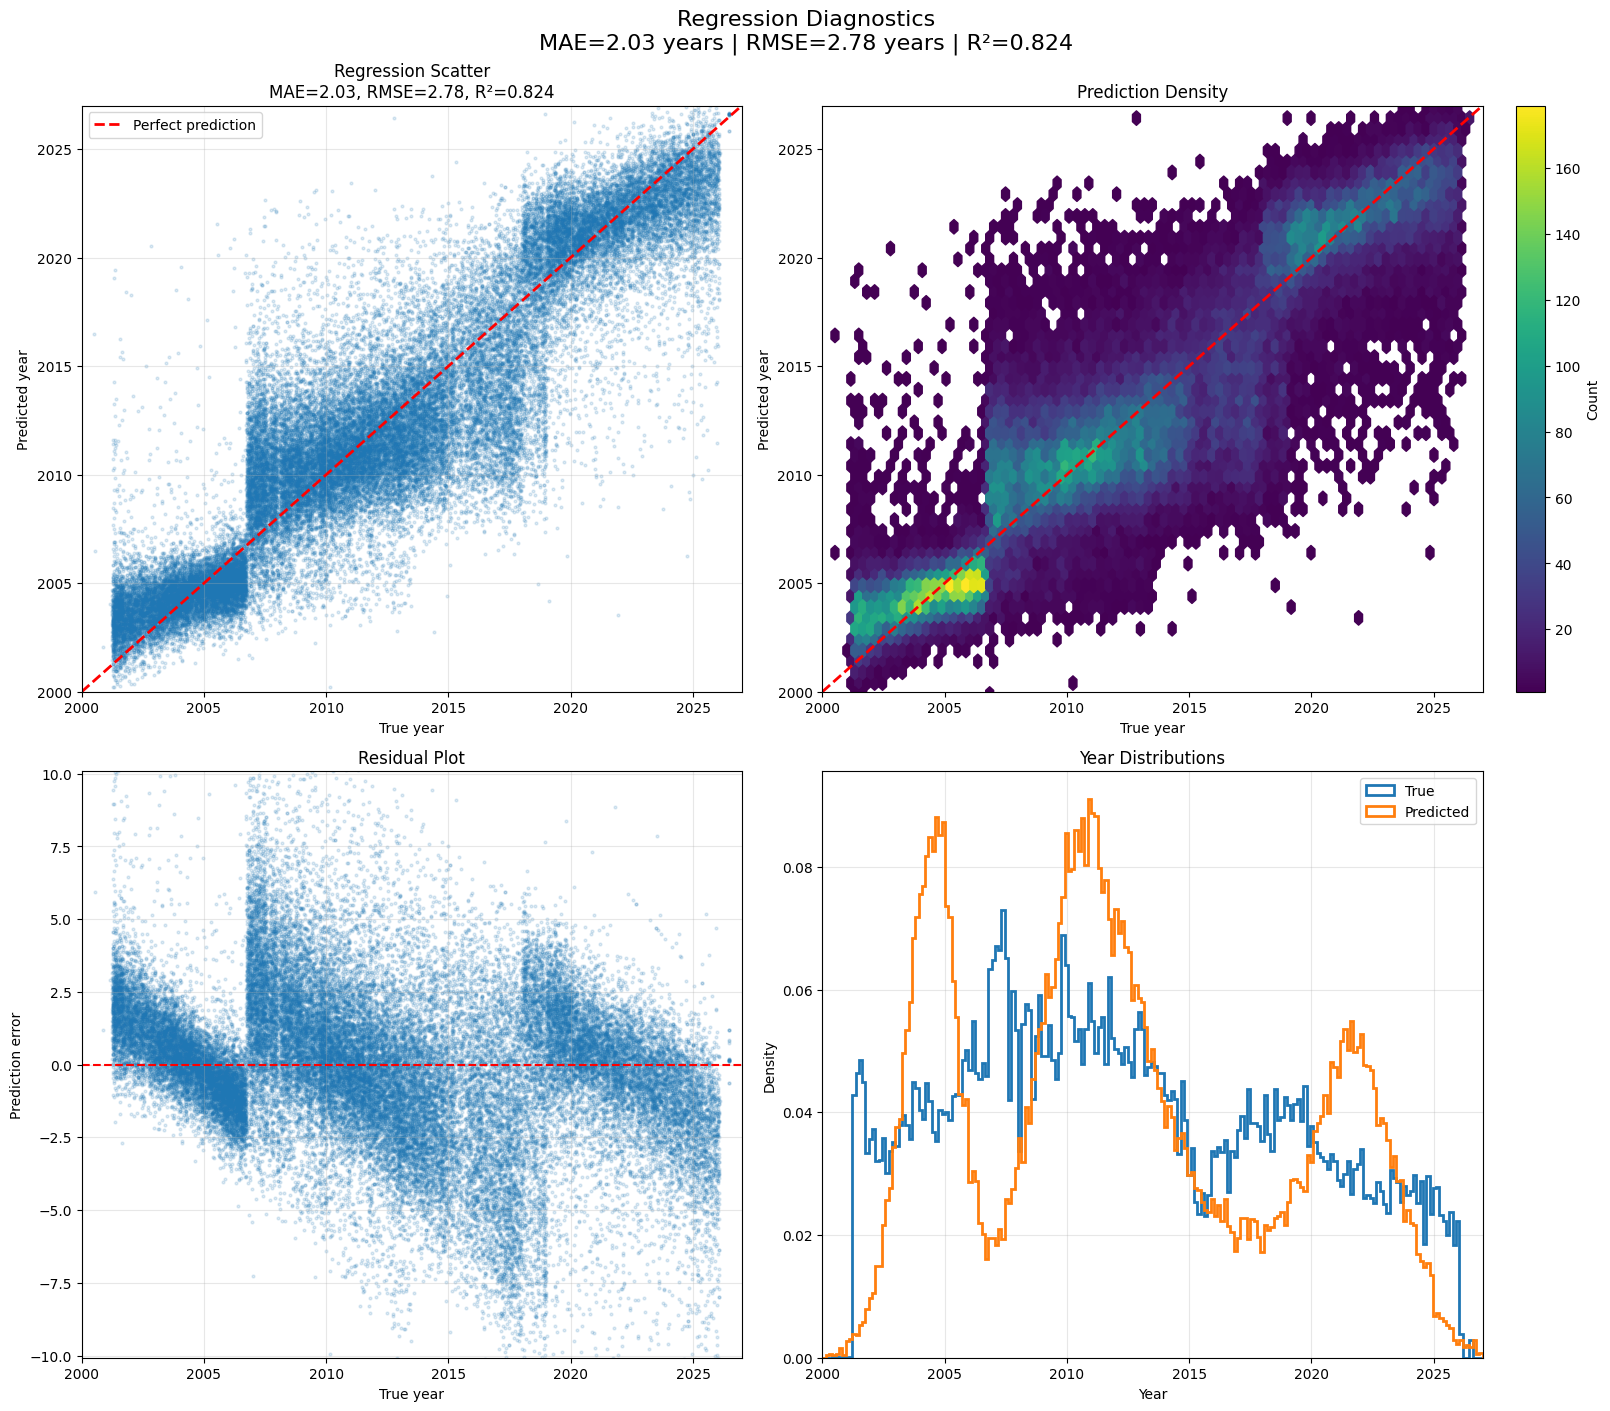

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# --------------------------------------------------
# FIXED YEAR LIMITS
# --------------------------------------------------

year_min = 2000
year_max = 2027

residuals = predicted_test_years - true_test_years

res_lim = np.percentile(
    np.abs(residuals),
    99.5
)

# --------------------------------------------------
# CREATE FIGURE
# --------------------------------------------------

fig, axs = plt.subplots(
    2,
    2,
    figsize=(16, 14),
    constrained_layout=True
)

# ==================================================
# (1) REGRESSION SCATTER
# ==================================================

axs[0, 0].scatter(
    true_test_years,
    predicted_test_years,
    s=4,
    alpha=0.15
)

axs[0, 0].plot(
    [year_min, year_max],
    [year_min, year_max],
    "r--",
    linewidth=2,
    label="Perfect prediction"
)

axs[0, 0].set_xlim(year_min, year_max)
axs[0, 0].set_ylim(year_min, year_max)

axs[0, 0].set_xlabel("True year")
axs[0, 0].set_ylabel("Predicted year")

axs[0, 0].set_title(
    f"Regression Scatter\n"
    f"MAE={mae:.2f}, RMSE={rmse:.2f}, R²={r2:.3f}"
)

axs[0, 0].legend()
axs[0, 0].grid(alpha=0.3)

# ==================================================
# (2) HEXBIN DENSITY
# ==================================================

hb = axs[0, 1].hexbin(
    true_test_years,
    predicted_test_years,
    gridsize=80,
    mincnt=1
)

axs[0, 1].plot(
    [year_min, year_max],
    [year_min, year_max],
    "r--",
    linewidth=2
)

axs[0, 1].set_xlim(year_min, year_max)
axs[0, 1].set_ylim(year_min, year_max)

axs[0, 1].set_xlabel("True year")
axs[0, 1].set_ylabel("Predicted year")
axs[0, 1].set_title("Prediction Density")

fig.colorbar(
    hb,
    ax=axs[0, 1],
    label="Count"
)

# ==================================================
# (3) RESIDUAL PLOT
# ==================================================

axs[1, 0].scatter(
    true_test_years,
    residuals,
    s=4,
    alpha=0.15
)

axs[1, 0].axhline(
    0,
    color="red",
    linestyle="--"
)

axs[1, 0].set_xlim(year_min, year_max)
axs[1, 0].set_ylim(-res_lim, res_lim)

axs[1, 0].set_xlabel("True year")
axs[1, 0].set_ylabel("Prediction error")
axs[1, 0].set_title("Residual Plot")
axs[1, 0].grid(alpha=0.3)

# ==================================================
# (4) TRUE VS PREDICTED DISTRIBUTIONS
# ==================================================

bins = np.linspace(
    year_min,
    year_max,
    200
)

axs[1, 1].hist(
    true_test_years,
    bins=bins,
    density=True,
    histtype="step",
    linewidth=2,
    label="True"
)

axs[1, 1].hist(
    predicted_test_years,
    bins=bins,
    density=True,
    histtype="step",
    linewidth=2,
    label="Predicted"
)

axs[1, 1].set_xlim(year_min, year_max)

axs[1, 1].set_xlabel("Year")
axs[1, 1].set_ylabel("Density")
axs[1, 1].set_title("Year Distributions")
axs[1, 1].legend()
axs[1, 1].grid(alpha=0.3)

# ==================================================
# FIGURE TITLE
# ==================================================

fig.suptitle(
    f"Regression Diagnostics\n"
    f"MAE={mae:.2f} years | "
    f"RMSE={rmse:.2f} years | "
    f"R²={r2:.3f}",
    fontsize=16
)

plt.show()

DATASET SUMMARY
count    504327.000000
mean       2012.510935
std           6.639280
min        2000.105225
25%        2007.151855
50%        2011.760986
75%        2017.971436
max        2026.471436
Name: year_float, dtype: float64

Total articles: 504327
Unique exact dates: 9092
Unique integer years: 27
Unique day estimates: 350

Top 10 most populated years:
year_int
2007    30540
2011    27223
2010    27138
2009    26926
2006    26161
2008    25811
2012    25415
2013    24526
2005    22239
2004    20220
Name: count, dtype: int64

Top repeated exact dates:
year_float
2026.471    194
2011.791    168
2009.839    153
2007.441    152
2009.963    149
2007.482    148
2009.966    147
2009.433    147
2007.955    145
2007.480    144
2007.536    141
2006.996    139
2007.952    138
2007.253    136
2008.264    136
2006.974    132
2006.960    132
2010.230    130
2007.444    129
2007.286    129
Name: count, dtype: int64


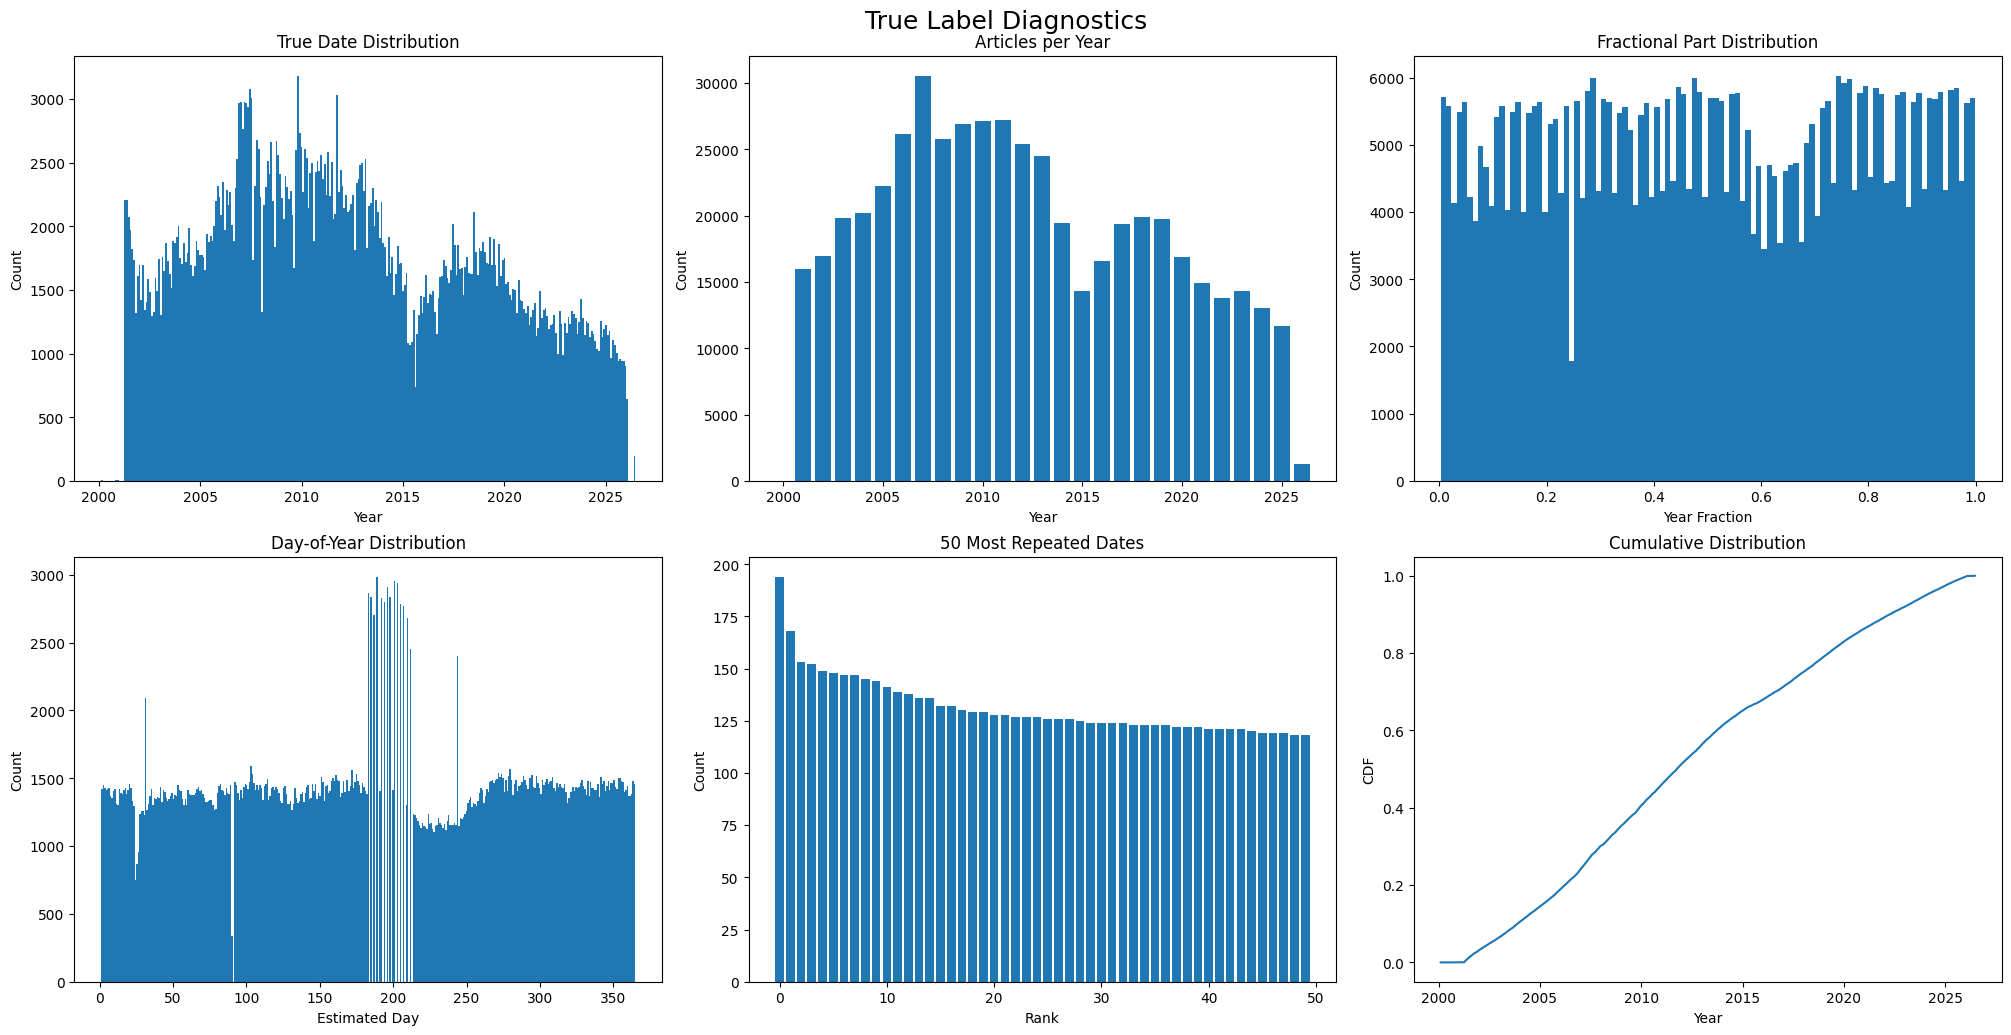


CLUSTERING DIAGNOSTICS
Largest year share : 6.06%
Top 3 years share  : 16.83%
Top 5 years share  : 27.36%
Year-distribution entropy: 4.609
Uniform entropy         : 4.755
Entropy ratio           : 0.969


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ==========================================
# PREPARE DATA
# ==========================================

y = np.asarray(y_years).astype(float)
y = y[~np.isnan(y)]

df = pd.DataFrame({
    "year_float": y,
    "year_int": np.floor(y).astype(int),
    "fraction": y % 1,
    "day_estimate": np.round((y % 1) * 365).astype(int)
})

year_counts = df["year_int"].value_counts().sort_index()
rounded_counts = df["year_float"].round(3).value_counts()

# ==========================================
# SUMMARY STATISTICS
# ==========================================

print("="*60)
print("DATASET SUMMARY")
print("="*60)

print(df["year_float"].describe())

print("\nTotal articles:", len(df))
print("Unique exact dates:", df["year_float"].nunique())
print("Unique integer years:", df["year_int"].nunique())
print("Unique day estimates:", df["day_estimate"].nunique())

print("\nTop 10 most populated years:")
print(year_counts.sort_values(ascending=False).head(10))

print("\nTop repeated exact dates:")
print(rounded_counts.head(20))

# ==========================================
# COMBINED FIGURE
# ==========================================

fig, axs = plt.subplots(
    2, 3,
    figsize=(20, 10),
    constrained_layout=True
)

# ------------------------------------------
# (1) Full date histogram
# ------------------------------------------

axs[0,0].hist(df["year_float"], bins=300)
axs[0,0].set_title("True Date Distribution")
axs[0,0].set_xlabel("Year")
axs[0,0].set_ylabel("Count")

# ------------------------------------------
# (2) Articles per integer year
# ------------------------------------------

axs[0,1].bar(year_counts.index, year_counts.values)
axs[0,1].set_title("Articles per Year")
axs[0,1].set_xlabel("Year")
axs[0,1].set_ylabel("Count")

# ------------------------------------------
# (3) Fractional year distribution
# ------------------------------------------

axs[0,2].hist(df["fraction"], bins=100)
axs[0,2].set_title("Fractional Part Distribution")
axs[0,2].set_xlabel("Year Fraction")
axs[0,2].set_ylabel("Count")

# ------------------------------------------
# (4) Day-of-year distribution
# ------------------------------------------

axs[1,0].hist(df["day_estimate"], bins=365)
axs[1,0].set_title("Day-of-Year Distribution")
axs[1,0].set_xlabel("Estimated Day")
axs[1,0].set_ylabel("Count")

# ------------------------------------------
# (5) Top repeated dates
# ------------------------------------------

top50 = rounded_counts.head(50)

axs[1,1].bar(
    np.arange(len(top50)),
    top50.values
)

axs[1,1].set_title("50 Most Repeated Dates")
axs[1,1].set_xlabel("Rank")
axs[1,1].set_ylabel("Count")

# ------------------------------------------
# (6) CDF of years
# ------------------------------------------

sorted_years = np.sort(df["year_float"])
cdf = np.arange(len(sorted_years)) / len(sorted_years)

axs[1,2].plot(sorted_years, cdf)
axs[1,2].set_title("Cumulative Distribution")
axs[1,2].set_xlabel("Year")
axs[1,2].set_ylabel("CDF")

plt.suptitle(
    "True Label Diagnostics",
    fontsize=18,
    y=1.02
)

plt.show()

# ==========================================
# EXTRA CLUSTERING METRICS
# ==========================================

print("\n" + "="*60)
print("CLUSTERING DIAGNOSTICS")
print("="*60)

largest_year_share = year_counts.max()/len(df)
top3_share = year_counts.sort_values(ascending=False).head(3).sum()/len(df)
top5_share = year_counts.sort_values(ascending=False).head(5).sum()/len(df)

print(f"Largest year share : {largest_year_share:.2%}")
print(f"Top 3 years share  : {top3_share:.2%}")
print(f"Top 5 years share  : {top5_share:.2%}")

# Entropy measure
p = year_counts.values / year_counts.values.sum()
entropy = -(p*np.log2(p)).sum()

print(f"Year-distribution entropy: {entropy:.3f}")

# Compare with uniform distribution
uniform_entropy = np.log2(len(year_counts))
print(f"Uniform entropy         : {uniform_entropy:.3f}")

print(
    f"Entropy ratio           : "
    f"{entropy/uniform_entropy:.3f}"
)

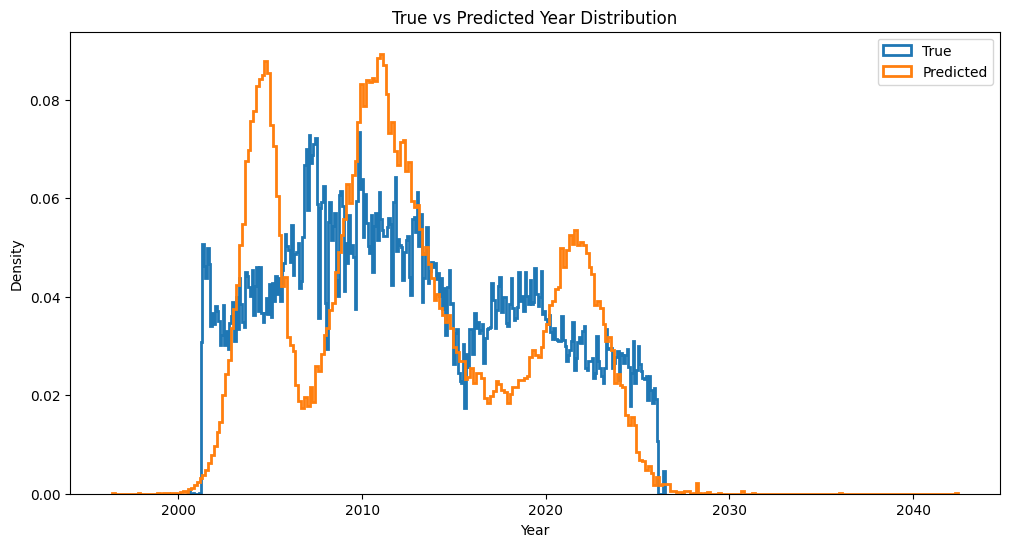

In [ ]:
plt.figure(figsize=(12,6))

plt.hist(
    true_test_years,
    bins=300,
    density=True,
    histtype="step",
    linewidth=2,
    label="True"
)

plt.hist(
    predicted_test_years,
    bins=300,
    density=True,
    histtype="step",
    linewidth=2,
    label="Predicted"
)

plt.xlabel("Year")
plt.ylabel("Density")
plt.title("True vs Predicted Year Distribution")
plt.legend()

plt.show()